In [6]:
import pandas as pd 
df_sku= pd.read_csv('sku_master.csv')
df_sales=pd.read_csv('sales_daily.csv')
df_calendar=pd.read_csv('calendar.csv')
df_inventory=pd.read_csv('inventory_snapshots.csv')
df_sku['category']=df_sku['category'].str.strip().str.title()
df_sales['date']=pd.to_datetime(df_sales['date'])
df_sales_pipeline=pd.merge(df_sales ,df_sku, on='sku_id', how ='left')

df_sales_pipeline.to_csv('cleaned_sales_pipeline.csv', index= False)
print(df_sales_pipeline.head())
# ceck the missing values :- 
print(df_sales_pipeline.isnull().sum())

        date   sku_id  units_sold   revenue  unit_price  promo_flag  \
0 2024-01-01  SKU_003         2.0  11810.54     5905.27           1   
1 2024-01-01  SKU_004         4.0  14145.16     3536.29           1   
2 2024-01-01  SKU_006         2.0   3008.04     1504.02           1   
3 2024-01-01  SKU_007         6.0  24930.96     4155.16           1   
4 2024-01-01  SKU_008         1.0   1731.76     1731.76           1   

           category    subcategory launch_date  unit_cost  list_price  
0  Small Appliances  Coffee Makers  2023-07-11    3290.69     7077.75  
1       Furnishings        Bedding  2023-02-18    2432.69     4246.40  
2             Décor       Wall Art  2023-11-16    1018.58     1845.04  
3       Furnishings           Rugs  2023-10-01    3109.34     5473.68  
4       Furnishings       Cushions  2023-12-06    1475.07     2180.36  
date             0
sku_id           0
units_sold     716
revenue        716
unit_price       0
promo_flag       0
category         0
subcateg

In [7]:
print(" 1. TOP PERFORMING CATEGORIES BY REVENUE")
category_revenue = df_sales_pipeline.groupby('category')['revenue'].sum().sort_values(ascending=False)
print(category_revenue)

print("\n 2.TOTAL UNITS SOLD BY SUBCATEGORY")
# See which specific items move the fastest
subcategory_volume = df_sales_pipeline.groupby('subcategory')['units_sold'].sum().sort_values(ascending=False)
print(subcategory_volume)

print("\n3. QUICK TRANSACTION SUMMARY ")
# Get an average of how much revenue a typical sale brings in
print(df_sales_pipeline[['units_sold', 'revenue']].mean())
# As results are in sceintific nototaion we are usinf this to conveert them into human readable formaat 
pd.options.display.float_format='{: .2f}'.format
print(" CLEAN REVENUE NUMBERS")

print(category_revenue)

 1. TOP PERFORMING CATEGORIES BY REVENUE
category
Furnishings         4.737145e+08
Small Appliances    3.334183e+08
Décor               3.146917e+08
Name: revenue, dtype: float64

 2.TOTAL UNITS SOLD BY SUBCATEGORY
subcategory
Bedding          44403.0
Coffee Makers    41138.0
Wall Art         36667.0
Cushions         33374.0
Rugs             28857.0
Blenders         27130.0
Vases            25574.0
Lighting         24252.0
Kitchenware      24040.0
Name: units_sold, dtype: float64

3. QUICK TRANSACTION SUMMARY 
units_sold        3.160159
revenue       12420.142444
dtype: float64
 CLEAN REVENUE NUMBERS
category
Furnishings         473714458.15
Small Appliances    333418320.37
Décor               314691747.44
Name: revenue, dtype: float64


In [8]:
print("1. TOP 5 HIGHEST MARGIN PRODUCTS")
# Calculateing the  profit margin percentage: (Price - Cost) / Price
df_sku['profit_margin_%'] = ((df_sku['list_price'] - df_sku['unit_cost']) / df_sku['list_price']) * 100
top_margins = df_sku[['sku_id', 'subcategory', 'list_price', 'unit_cost', 'profit_margin_%']].sort_values(by='profit_margin_%', ascending=False)
print(top_margins.head())

print("\n2. ARE THERE ANY NEGATIVE MARGIN PRODUCTS?")
# Checking  if any item is being sold at a loss or not 
loss_making = df_sku[df_sku['unit_cost'] > df_sku['list_price']]
if loss_making.empty:
    print("Great news! No products are being sold at a loss.")
else:
    print(loss_making[['sku_id', 'subcategory', 'list_price', 'unit_cost']])

print("\n 3. INITIAL INVENTORY HEALTH SNAPSHOT")
# Looking  at total daily stock records loaded
print(f"Total inventory records ready for analysis: {len(df_inventory)}")

1. TOP 5 HIGHEST MARGIN PRODUCTS
      sku_id subcategory  list_price  unit_cost  profit_margin_%
199  SKU_200       Vases     5958.29    2708.95            54.53
132  SKU_133    Blenders     6992.93    3181.78            54.50
46   SKU_047    Blenders      745.82     339.68            54.46
198  SKU_199    Cushions     2436.00    1112.26            54.34
48   SKU_049     Bedding     5765.30    2639.47            54.22

2. ARE THERE ANY NEGATIVE MARGIN PRODUCTS?
Great news! No products are being sold at a loss.

 3. INITIAL INVENTORY HEALTH SNAPSHOT
Total inventory records ready for analysis: 20800


In [9]:

import pandas as pd

print("--- RE-LOADING DATAFRAMES INTO ACTIVE MEMORY ---")
# 1. Load the data files explicitly so the notebook remembers them
df_inventory = pd.read_csv('inventory_snapshots.csv')
df_sku = pd.read_csv('sku_master.csv')
print(f"Data successfully loaded! Inventory rows: {len(df_inventory)}, SKU rows: {len(df_sku)}")


print("\n--- STARTING INVENTORY PIPELINE JOIN ---")
# 2. Convert the date column to true datetime format
df_inventory['date'] = pd.to_datetime(df_inventory['date'])

# 3. Merge your inventory snapshots with the SKU master file
df_inventory_pipeline = pd.merge(df_inventory, df_sku, on='sku_id', how='left')
print("Merge complete!")
print(f"Combined table structure: {df_inventory_pipeline.shape}")


print("\n--- EXPORTING CLEAN DATA ---")
# 4. Export the clean data to your project folder
df_inventory_pipeline.to_csv('cleaned_inventory_pipeline.csv', index=False)
print("🎉 Success! 'cleaned_inventory_pipeline.csv' has been saved safely.")

--- RE-LOADING DATAFRAMES INTO ACTIVE MEMORY ---
Data successfully loaded! Inventory rows: 20800, SKU rows: 200

--- STARTING INVENTORY PIPELINE JOIN ---
Merge complete!
Combined table structure: (20800, 11)

--- EXPORTING CLEAN DATA ---
🎉 Success! 'cleaned_inventory_pipeline.csv' has been saved safely.


C:\Users\HARSHS\AppData\Local\Temp\ipykernel_16204\2396855693.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HARSHS\AppData\Local\Temp\ipykernel_16204\2396855693.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


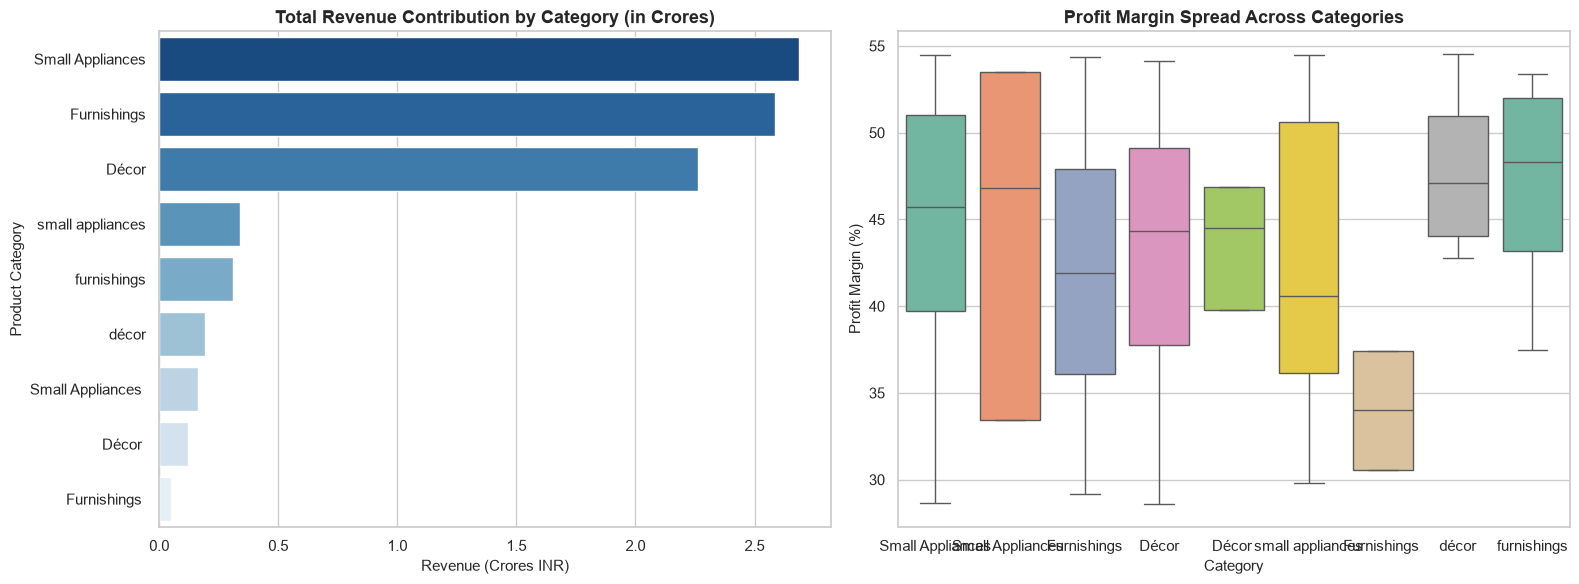

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recalculate profit margin so the boxplot has data to read
df_inventory_pipeline['profit_margin_%'] = ((df_inventory_pipeline['list_price'] - df_inventory_pipeline['unit_cost']) / df_inventory_pipeline['list_price']) * 100

# 2. Group the clean data to get the revenue bars right
category_sales = df_inventory_pipeline.groupby('category')['list_price'].sum().sort_values(ascending=False)

# 3. Tell the notebook to display the graphs cleanly inside your screen
%matplotlib inline
sns.set_theme(style="whitegrid")

# 4. Create a canvas layout for two charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- CHART 1: Bar Plot of Revenue Categories ---
sns.barplot(
    x=category_sales.values / 1e7,  # Scaling to Crores for clean presentation numbers
    y=category_sales.index, 
    ax=axes[0], 
    palette="Blues_r"
)
axes[0].set_title("Total Revenue Contribution by Category (in Crores)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Revenue (Crores INR)", fontsize=11)
axes[0].set_ylabel("Product Category", fontsize=11)

# --- CHART 2: Box Plot of Profit Margin Spreads ---
sns.boxplot(
    x='category', 
    y='profit_margin_%', 
    data=df_inventory_pipeline, 
    ax=axes[1], 
    palette="Set2"
)
axes[1].set_title("Profit Margin Spread Across Categories", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Category", fontsize=11)
axes[1].set_ylabel("Profit Margin (%)", fontsize=11)

plt.tight_layout()
plt.show()

In [13]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\HARSHS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
